In [1]:
# import libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

#load dataset
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

(569, 30)
(569,)


In [2]:
# Logistic Regression
class LogisticRegression:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0
        self.losses = []

        for _ in range(self.epochs):

            linear_model = np.dot(X, self.weights) + self.bias

            predictions = self.sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (predictions - y))

            db = (1 / n_samples) * np.sum(predictions - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            epsilon = 1e-15
            loss = -np.mean(
                y * np.log(predictions + epsilon) +
                (1 - y) * np.log(1 - predictions + epsilon)
            )
            self.losses.append(loss)

    def predict_proba(self, X):

        linear_model = np.dot(X, self.weights) + self.bias

        return self.sigmoid(linear_model)

    def predict(self, X):

        probabilities = self.predict_proba(X)

        return np.where(probabilities >= 0.5, 1, 0)

In [3]:
# LDA
class LDA:

    def fit(self, X, y):

        self.classes = np.unique(y)

        n_features = X.shape[1]

        self.means = {}
        self.priors = {}

        covariance = np.zeros((n_features, n_features))

        for c in self.classes:

            X_c = X[y == c]

            self.means[c] = np.mean(X_c, axis=0)

            self.priors[c] = X_c.shape[0] / X.shape[0]

            covariance += np.cov(X_c, rowvar=False) * (X_c.shape[0] - 1)

        covariance /= (X.shape[0] - len(self.classes))

        self.covariance = covariance

        self.inv_covariance = np.linalg.inv(covariance)

    def _discriminant(self, x, c):

        mean = self.means[c]

        term1 = x @ self.inv_covariance @ mean

        term2 = -0.5 * mean @ self.inv_covariance @ mean

        term3 = np.log(self.priors[c])

        return term1 + term2 + term3

    def predict(self, X):

        predictions = []

        for x in X:

            scores = [
                self._discriminant(x, c)
                for c in self.classes
            ]

            predictions.append(self.classes[np.argmax(scores)])

        return np.array(predictions)

In [4]:
#QDA
class QDA:

    def fit(self, X, y):

        self.classes = np.unique(y)

        self.means = {}
        self.priors = {}
        self.covariances = {}
        self.inv_covariances = {}
        self.det_covariances = {}

        for c in self.classes:

            X_c = X[y == c]

            self.means[c] = np.mean(X_c, axis=0)

            self.priors[c] = len(X_c) / len(X)

            cov = np.cov(X_c, rowvar=False)

            # Small regularization
            cov += 1e-6 * np.eye(cov.shape[0])

            self.covariances[c] = cov

            self.inv_covariances[c] = np.linalg.inv(cov)

            self.det_covariances[c] = np.linalg.det(cov)

    def _discriminant(self, x, c):

        mean = self.means[c]

        inv_cov = self.inv_covariances[c]

        det_cov = self.det_covariances[c]

        prior = self.priors[c]

        diff = x - mean

        term1 = -0.5 * np.log(det_cov)

        term2 = -0.5 * (diff @ inv_cov @ diff)

        term3 = np.log(prior)

        return term1 + term2 + term3

    def predict(self, X):

        predictions = []

        for x in X:

            scores = [
                self._discriminant(x, c)
                for c in self.classes
            ]

            predictions.append(
                self.classes[np.argmax(scores)]
            )

        return np.array(predictions)

In [5]:
logistic_model = LogisticRegression()
lda_model = LDA()
qda_model = QDA()

logistic_model.fit(
    X_train,
    y_train
)

lda_model.fit(
    X_train,
    y_train
)

qda_model.fit(
    X_train,
    y_train
)

In [6]:
logistic_pred = logistic_model.predict(
    X_test
)

lda_pred = lda_model.predict(
    X_test
)

qda_pred = qda_model.predict(
    X_test
)

In [7]:
logistic_acc = accuracy_score(
    y_test,
    logistic_pred
)

lda_acc = accuracy_score(
    y_test,
    lda_pred
)

qda_acc = accuracy_score(
    y_test,
    qda_pred
)

print("\nLogistic Accuracy:", logistic_acc)
print("LDA Accuracy:", lda_acc)
print("QDA Accuracy:", qda_acc)


Logistic Accuracy: 0.9824561403508771
LDA Accuracy: 0.956140350877193
QDA Accuracy: 0.956140350877193


In [8]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_pred
)

cm_lda = confusion_matrix(
    y_test,
    lda_pred
)

cm_qda = confusion_matrix(
    y_test,
    qda_pred
)

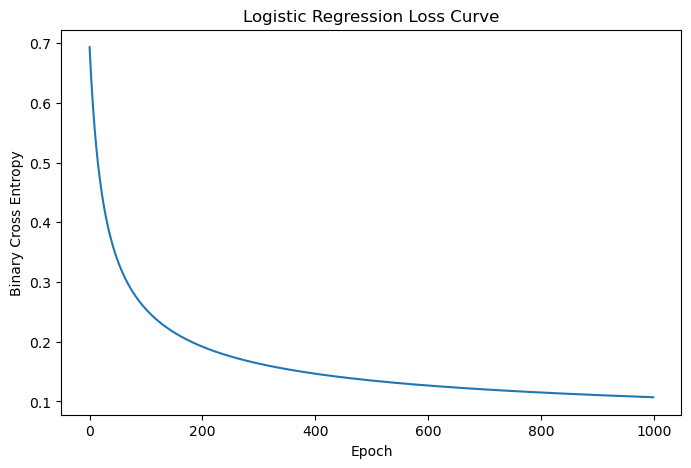

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
plt.plot(
    logistic_model.losses
)

plt.title(
    "Logistic Regression Loss Curve"
)

plt.xlabel("Epoch")
plt.ylabel(
    "Binary Cross Entropy"
)

plt.show()

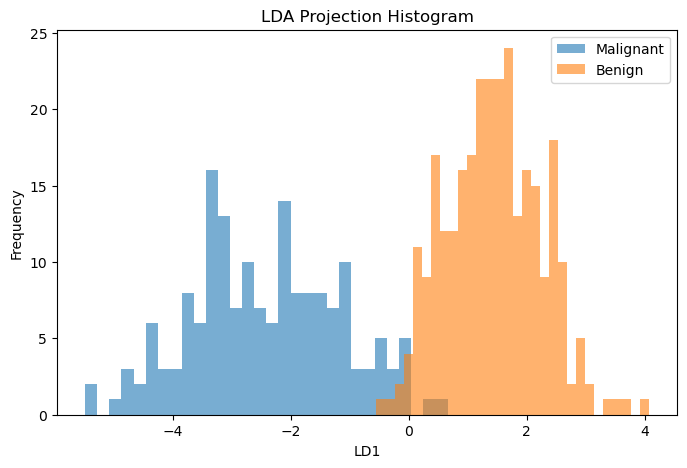

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_vis = LinearDiscriminantAnalysis(
    n_components=1
)

X_lda = lda_vis.fit_transform(
    X_train,
    y_train
)

plt.figure(figsize=(8,5))

plt.hist(
    X_lda[y_train == 0],
    bins=30,
    alpha=0.6,
    label="Malignant"
)

plt.hist(
    X_lda[y_train == 1],
    bins=30,
    alpha=0.6,
    label="Benign"
)

plt.title(
    "LDA Projection Histogram"
)

plt.xlabel("LD1")
plt.ylabel("Frequency")

plt.legend()

plt.show()

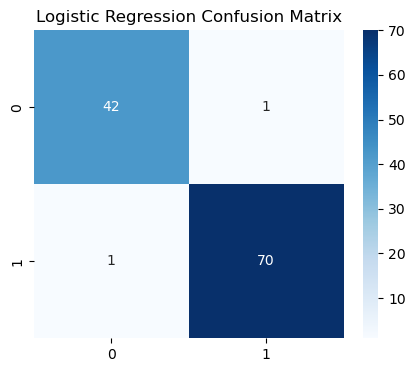

In [12]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


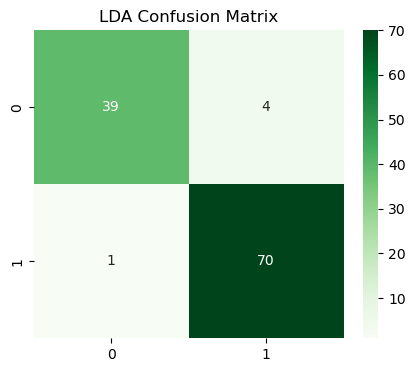

In [13]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lda,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "LDA Confusion Matrix"
)

plt.show()

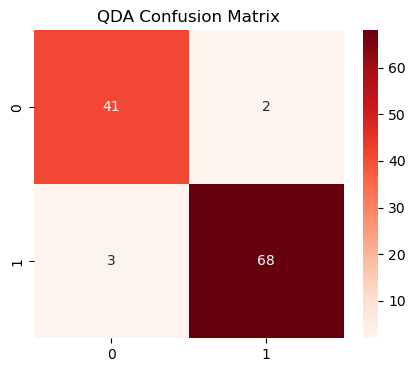

In [14]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_qda,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title(
    "QDA Confusion Matrix"
)

plt.show()

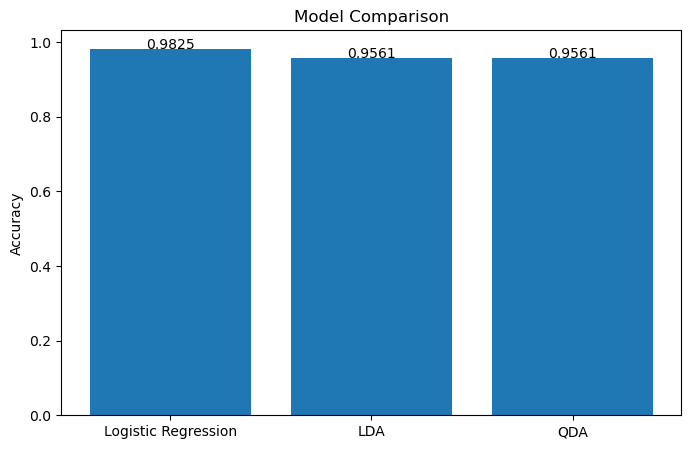

In [15]:
models = [
    "Logistic Regression",
    "LDA",
    "QDA"
]

accuracies = [
    logistic_acc,
    lda_acc,
    qda_acc
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    accuracies
)

plt.ylabel("Accuracy")

plt.title(
    "Model Comparison"
)

for bar in bars:

    plt.text(
        bar.get_x()
        + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha="center"
    )

plt.show()